**Micro-Doppler Signature Extraction and Classification using STFT and Machine Learning**

Libraries


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import pandas as pd
import time
import random

Parameters

In [ ]:
fs = 1000
duration = 2
t = np.linspace(0, duration, fs * duration)

Signal functions

In [ ]:
def drone_signal():
    return np.cos(2*np.pi*50*t + 5*np.sin(2*np.pi*10*t))

def human_signal():
    return np.cos(2*np.pi*20*t + 2*np.sin(2*np.pi*2*t))

def bird_signal():
    return np.cos(2*np.pi*35*t + 8*np.sin(2*np.pi*8*t)) * (1 + 0.5*np.sin(2*np.pi*4*t))

Time Signal Plot Functions

In [ ]:
def plot_time_signal(signal, title):
    plt.figure()
    plt.plot(t, signal)
    plt.title(title + " - Time Domain Signal")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid()
    plt.show()

Time Doman Visuals

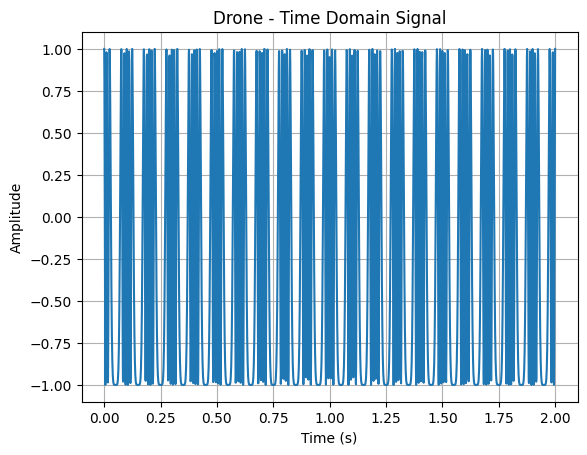

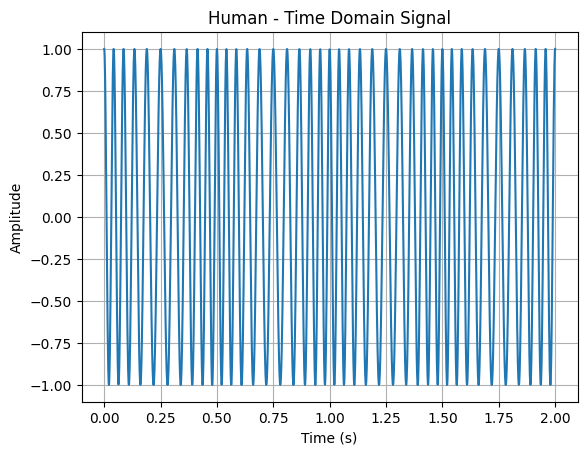

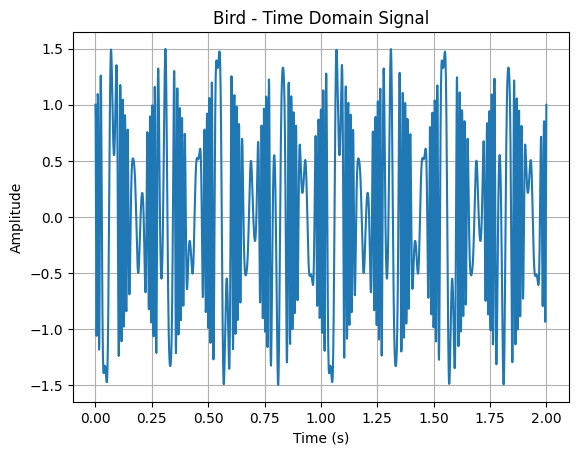

In [ ]:
plot_time_signal(drone_signal(), "Drone")
plot_time_signal(human_signal(), "Human")
plot_time_signal(bird_signal(), "Bird")

Noise function

In [ ]:
def add_noise(signal, noise_level=0.5):
    noise = np.random.normal(0, noise_level, len(signal))
    return signal + noise

Noise added siganl

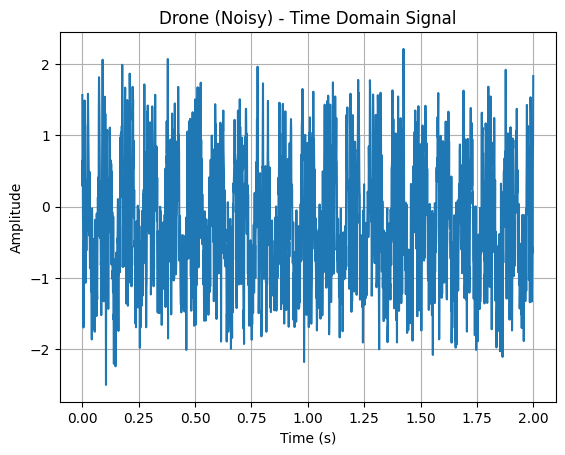

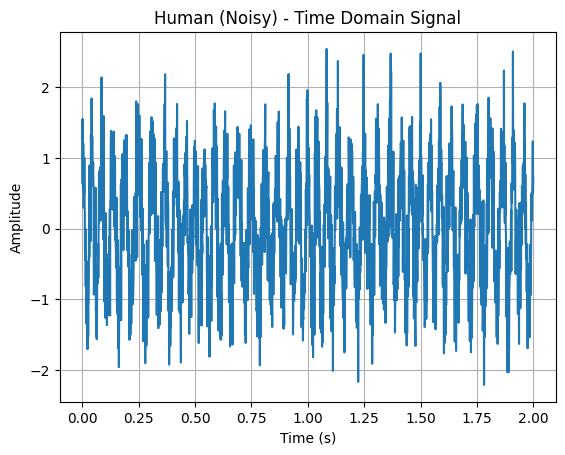

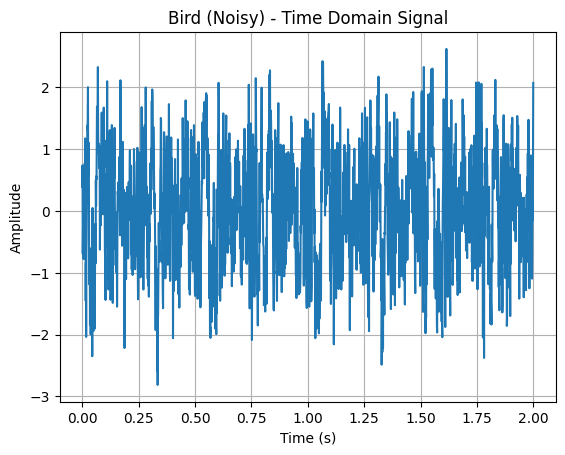

In [ ]:
plot_time_signal(add_noise(drone_signal()), "Drone (Noisy)")
plot_time_signal(add_noise(human_signal()), "Human (Noisy)")
plot_time_signal(add_noise(bird_signal()), "Bird (Noisy)")

FFT of signals

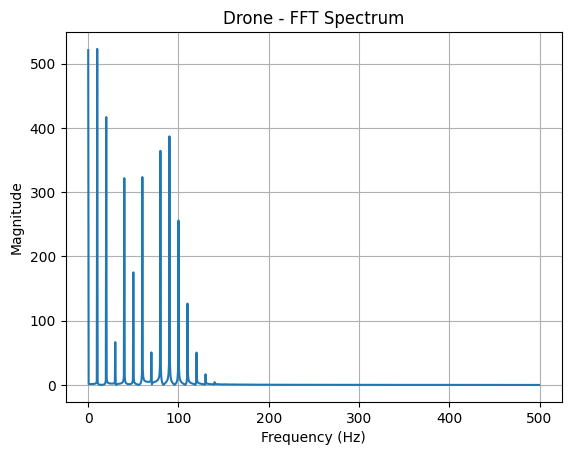

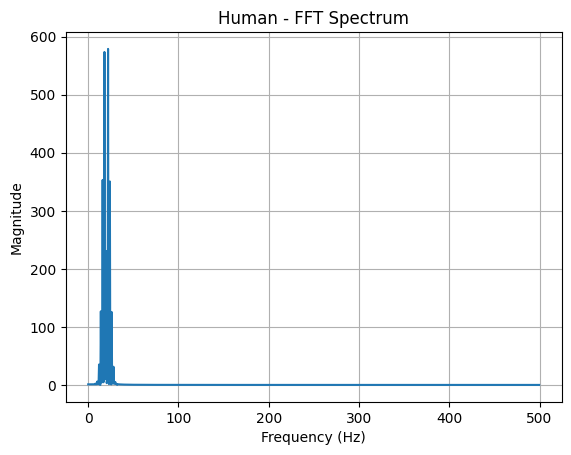

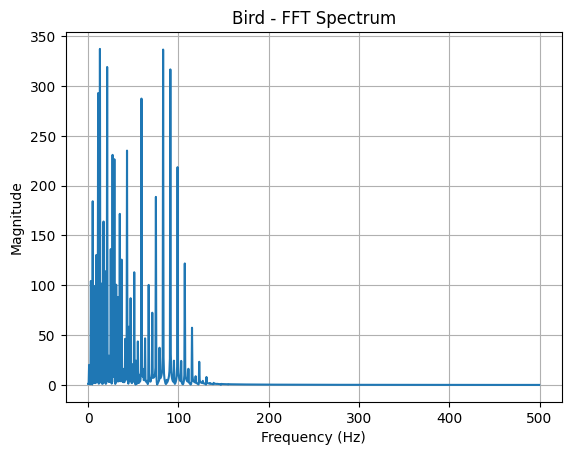

In [ ]:
def plot_fft(signal, title):
    N = len(signal)

    fft_vals = np.fft.fft(signal)
    fft_vals = np.abs(fft_vals[:N//2])  # take positive frequencies

    freqs = np.fft.fftfreq(N, 1/fs)[:N//2]

    plt.figure()
    plt.plot(freqs, fft_vals)
    plt.title(title + " - FFT Spectrum")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid()
    plt.show()

plot_fft(drone_signal(), "Drone")
plot_fft(human_signal(), "Human")
plot_fft(bird_signal(), "Bird")

STFT Function

In [ ]:
def compute_spectrogram(signal):
    f, t_spec, Zxx = stft(signal, fs=fs, nperseg=128)
    return f, t_spec, np.abs(Zxx)

Plot Function

In [ ]:
def plot_spectrogram(signal, title):
    f, t_spec, S = compute_spectrogram(signal)
    plt.figure()
    plt.pcolormesh(t_spec, f, S, shading='gouraud')
    plt.title(title)
    plt.ylabel('Frequency (Hz)')
    plt.xlabel('Time (s)')
    plt.colorbar()
    plt.show()

STFT Spectrum Visualisation

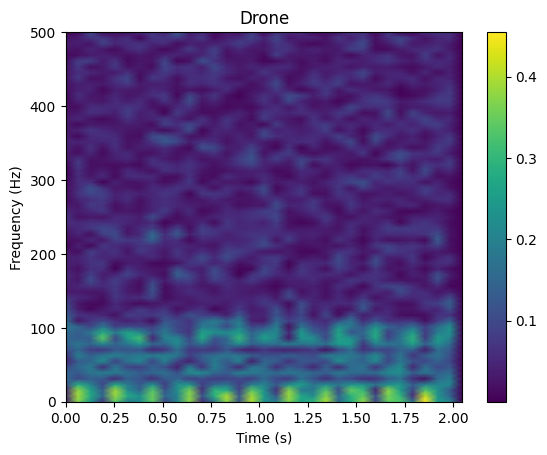

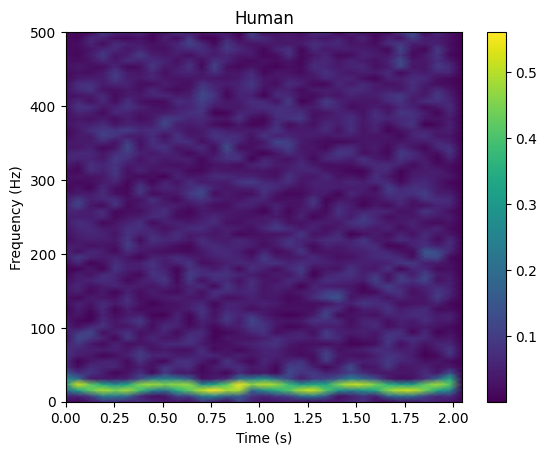

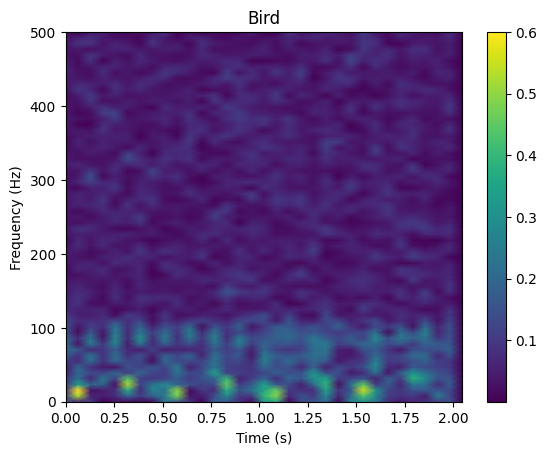

In [ ]:
plot_spectrogram(add_noise(drone_signal()), "Drone")
plot_spectrogram(add_noise(human_signal()), "Human")
plot_spectrogram(add_noise(bird_signal()), "Bird")

Feature Extraction

In [ ]:
def extract_features(S):
    features = []

    # Energy features
    features.append(np.mean(S))
    features.append(np.std(S))
    features.append(np.max(S))

    # Frequency behavior
    dominant_freq = np.argmax(S, axis=0)
    features.append(np.mean(dominant_freq))
    features.append(np.std(dominant_freq))

    # Spectral spread
    features.append(np.var(S))

    # Entropy (important for pattern complexity)
    S_norm = S / np.sum(S)
    entropy = -np.sum(S_norm * np.log(S_norm + 1e-8))
    features.append(entropy)

    return features

Dataset Creation

In [ ]:
X = []
y = []

for _ in range(100):
    sig = add_noise(drone_signal())
    _, _, S = compute_spectrogram(sig)
    X.append(extract_features(S))
    y.append(0)

    sig = add_noise(human_signal())
    _, _, S = compute_spectrogram(sig)
    X.append(extract_features(S))
    y.append(1)

    sig = add_noise(bird_signal())
    _, _, S = compute_spectrogram(sig)
    X.append(extract_features(S))
    y.append(2)

X = np.array(X)
y = np.array(y)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

Training

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = SVC(kernel='rbf', C=10, gamma='scale')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Results

              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       1.00      1.00      1.00        19
           2       1.00      0.95      0.98        21

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60



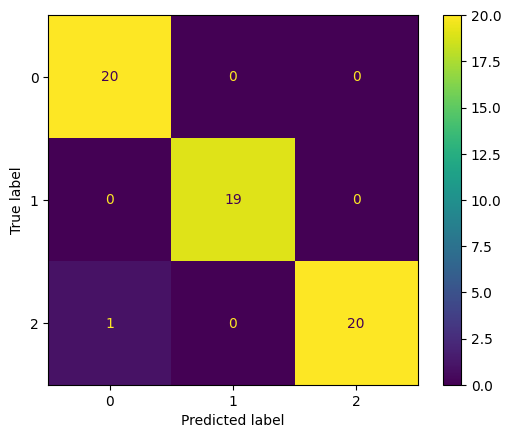

In [ ]:
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()